# Topic Driven Sentiment Analysis of U.S. Senators’ Tweets


Data file: https://github.com/vjavaly/Baruch-CIS-9665/blob/main/data/US_senators_2020_tweets_73k.csv

**Install Libraries**

In [ ]:
!pip install gensim bertopic sentence-transformers umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.0 MB/s eta 0:00:00


**Imports and Downloads**

In [ ]:
import os
import html
import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from bs4 import BeautifulSoup
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models import CoherenceModel
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

In [ ]:
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('vader_lexicon')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

# **Prepare Data**

**Load data**

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9665/refs/heads/main/data/US_senators_2020_tweets_73k.csv')

**Examine data**

In [ ]:
print("Number of rows and columns: ",df.shape,"\n")
pd.set_option('display.max_colwidth', None)
df.head(5)

Number of rows and columns:  (73111, 6) 



,Unnamed: 0,username,date,tweet_id,tweet_content,tweet_url
0,0,lisamurkowski,2020-12-31 18:06:21+00:00,1344706472052142083,Alaskans have proven their resilience time and time again in the face of disaster. I remain committed to helping equip them with the tools and resources they need to keep Alaskans across the state as safe as possible. https://t.co/T2M6Oh1SyA,https://twitter.com/lisamurkowski/status/1344706472052142083
1,1,lisamurkowski,2020-12-31 18:06:20+00:00,1344706470055714819,"I’m proud that my Interior Appropriations bill, which was recently signed into law, takes important steps to further develop &amp; improve earthquake &amp; volcano monitoring capabilities, modernize 3D Alaska mapping, &amp; provide support for wildland fire management &amp; suppression. https://t.co/2uTgDOvarn",https://twitter.com/lisamurkowski/status/1344706470055714819
2,2,lisamurkowski,2020-12-30 01:13:26+00:00,1344089179207118848,"I’m proud that the nearly $900 billion #COVID19 Relief package, which was recently signed into law, includes significant funding to support another round of #PPP to our hardest-hit small businesses in desperate need of assistance. https://t.co/m2rmAy7VZq",https://twitter.com/lisamurkowski/status/1344089179207118848
3,3,lisamurkowski,2020-12-30 01:13:26+00:00,1344089177663688704,The Paycheck Protection Program has been critical in helping American workers and small businesses navigate the #COVID19 pandemic. https://t.co/OnI8r8Ek4t,https://twitter.com/lisamurkowski/status/1344089177663688704
4,4,lisamurkowski,2020-12-29 00:59:39+00:00,1343723320030744578,"Reaching this agreement took significant bipartisan compromise from members across the board, and I’m proud to have been a part of that good work. The President’s decision to sign this legislation without further delay, which includes critical #COVID19 relief, is welcomed news.",https://twitter.com/lisamurkowski/status/1343723320030744578


In [ ]:
# Check datatypes
print(df.dtypes,"\n")

# Check for null values
print("Null values in each column:",df.isnull().sum(),"\n")

# Check for duplicated rows
print("Number of duplicate rows: ",df.duplicated().sum())

Unnamed: 0        int64
username         object
date             object
tweet_id          int64
tweet_content    object
tweet_url        object
dtype: object 

Null values in each column: Unnamed: 0       0
username         0
date             0
tweet_id         0
tweet_content    0
tweet_url        0
dtype: int64 

Number of duplicate rows:  0


In [ ]:
# Drop unnecessary columns
columns_to_drop = ['Unnamed: 0','tweet_id', 'tweet_url']
df = df.drop(columns=columns_to_drop)

**Cleaning functions for BERT**




In [ ]:
# Function to clean_text for BERT

def clean_text_bert(text):
# [AI-START] The following block was generated by ChatGPT
# Prompted the AI to: steps on removing HTML/text content in Python

  # Fix &amp; &lt; &gt;
  text = html.unescape(text)

  # Remove HTML tags
  text = BeautifulSoup(text, "html.parser").get_text()

# [AI-END]

  # Lowercase the text
  text = text.lower()

  # Remove URLs
  text = re.sub(r'http\S+|www\S+|https\S+', '', text)

  # Remove mentions (@user)
  text = re.sub(r'@\w+', '', text)

  # Keep hashtags but remove '#'
  text = re.sub(r'#', '', text)

  # Remove special characters but KEEP punctuation like .,!?
  text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)

  # Remove extra spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

**Cleaning functions for LDA**

In [ ]:
# Initialize the WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# Create stopwords set
stop_words = set(stopwords.words('english'))

# Function to get the part of speech tag for lemmatization
def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)


# Function to clean_text for LDA
def clean_text_lda(text):

    # Fix &amp; &lt; &gt;
    text = html.unescape(text)

    # Lowercase the text
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags symbol only
    text = re.sub(r'#', '', text)

    # Remove punctuation + numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize
    tokens = text.split()

    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens]
    return ' '.join(tokens)

**Apply cleaning**

In [ ]:
%%time
# Apply cleaning for LDA and BERTopic

df['cleaned_tweet_content_LDA'] = df['tweet_content'].apply(clean_text_lda)
df['cleaned_tweet_content_BERT'] = df['tweet_content'].apply(clean_text_bert)
df[['tweet_content', 'cleaned_tweet_content_LDA','cleaned_tweet_content_BERT']].head()

CPU times: user 1min 56s, sys: 611 ms, total: 1min 56s
Wall time: 2min


,tweet_content,cleaned_tweet_content_LDA,cleaned_tweet_content_BERT
0,Alaskans have proven their resilience time and time again in the face of disaster. I remain committed to helping equip them with the tools and resources they need to keep Alaskans across the state as safe as possible. https://t.co/T2M6Oh1SyA,alaskan proven resilience time time face disaster remain commit help equip tool resource need keep alaskan across state safe possible,alaskans have proven their resilience time and time again in the face of disaster. i remain committed to helping equip them with the tools and resources they need to keep alaskans across the state as safe as possible.
1,"I’m proud that my Interior Appropriations bill, which was recently signed into law, takes important steps to further develop &amp; improve earthquake &amp; volcano monitoring capabilities, modernize 3D Alaska mapping, &amp; provide support for wildland fire management &amp; suppression. https://t.co/2uTgDOvarn",im proud interior appropriation bill recently sign law take important step develop improve earthquake volcano monitoring capability modernize alaska mapping provide support wildland fire management suppression,"im proud that my interior appropriations bill, which was recently signed into law, takes important steps to further develop improve earthquake volcano monitoring capabilities, modernize 3d alaska mapping, provide support for wildland fire management suppression."
2,"I’m proud that the nearly $900 billion #COVID19 Relief package, which was recently signed into law, includes significant funding to support another round of #PPP to our hardest-hit small businesses in desperate need of assistance. https://t.co/m2rmAy7VZq",im proud nearly billion covid relief package recently sign law include significant funding support another round ppp hardesthit small business desperate need assistance,"im proud that the nearly 900 billion covid19 relief package, which was recently signed into law, includes significant funding to support another round of ppp to our hardesthit small businesses in desperate need of assistance."
3,The Paycheck Protection Program has been critical in helping American workers and small businesses navigate the #COVID19 pandemic. https://t.co/OnI8r8Ek4t,paycheck protection program critical help american worker small business navigate covid pandemic,the paycheck protection program has been critical in helping american workers and small businesses navigate the covid19 pandemic.
4,"Reaching this agreement took significant bipartisan compromise from members across the board, and I’m proud to have been a part of that good work. The President’s decision to sign this legislation without further delay, which includes critical #COVID19 relief, is welcomed news.",reach agreement take significant bipartisan compromise member across board im proud part good work president decision sign legislation without delay include critical covid relief welcome news,"reaching this agreement took significant bipartisan compromise from members across the board, and im proud to have been a part of that good work. the presidents decision to sign this legislation without further delay, which includes critical covid19 relief, is welcomed news."


**Bag of Words for LDA**

In [ ]:
texts = [t.split() for t in df['cleaned_tweet_content_LDA']]

dictionary = Dictionary(texts)
dictionary.filter_extremes(no_below=20, no_above=0.5)

corpus = [dictionary.doc2bow(text) for text in texts]

# **Question 1**: Once major political topics are identified through topic modeling, how does sentiment differ across those topics in senators’ 2020 tweets?

Starting with the LDA technique for Topic Modeling

**Train LDA**

In [ ]:
lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    chunksize=4000,
    passes=1,
    iterations=50,
    random_state=42,
    alpha='auto',
    eta='auto'
)

We trained an LDA model with 10 topics using Gensim. We sued alpha = 'auto' and eta = 'auto' to allow the model to learn optimal topic and word sparsity. We set iterations = 50 and chunksize = 4000 to balance speed and stability. The model was trained on the bag-of-words corpus derived from our cleaned LDA text.

**LDA top words**

In [ ]:
for i,topic in lda.show_topics(num_topics=10, num_words=15, formatted=False):
    print(f"Topic {i}: {[word for word, _ in topic]}")

Topic 0: ['today', 'year', 'thank', 'honor', 'family', 'woman', 'virginia', 'work', 'day', 'west', 'service', 'proud', 'serve', 'nation', 'life']
Topic 1: ['bill', 'act', 'bipartisan', 'need', 'u', 'legislation', 'national', 'american', 'must', 'congress', 'im', 'letter', 'would', 'general', 'introduce']
Topic 2: ['need', 'covid', 'health', 'help', 'care', 'relief', 'provide', 'business', 'pandemic', 'support', 'work', 'test', 'family', 'funding', 'act']
Topic 3: ['senate', 'court', 'republican', 'judge', 'democrat', 'justice', 'supreme', 'barrett', 'vote', 'scotus', 'american', 'law', 'care', 'nominee', 'hearing']
Topic 4: ['trump', 'president', 'american', 'people', 'u', 'state', 'wisconsin', 'election', 'administration', 'republican', 'democrat', 'want', 'house', 'america', 'work']
Topic 5: ['people', 'american', 'right', 'must', 'u', 'life', 'time', 'one', 'year', 'lose', 'let', 'freedom', 'country', 'know', 'america']
Topic 6: ['watch', 'join', 'live', 'today', 'covid', 'question'

**Sentiment Analysis on Each Tweet**

In [ ]:
sia = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['tweet_content'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)
def label_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['sentiment_score'].apply(label_sentiment)

**Assign LDA Topics**

In [ ]:
def get_topic(doc_bow):
    topic_probs = lda.get_document_topics(doc_bow)
    return max(topic_probs, key=lambda x: x[1])[0]

df['LDA_topic'] = [get_topic(bow) for bow in corpus]

df['LDA_topic'].head()

,LDA_topic
0,8
1,7
2,2
3,2
4,2


**LDA labels**

In [ ]:
# Add human-readable LDA topic labels
lda_labels = {
    0: "Public Service, Recognition & National Observances",
    1: "Congressional Legislation & Bipartisan Bills",
    2: "COVID-19 Relief, Families & Economic Hardship",
    3: "Supreme Court, Barrett Nomination & Partisan Conflict",
    4: "Trump Administration, Justice & Political Accountability",
    5: "Healthcare Access, Public Health & COVID-19 Crisis",
    6: "Town Halls & Community Outreach",
    7: "Community Support, Jobs & Veterans",
    8: "COVID-19 Health, Testing & Vaccines",
    9: "Voting, Elections & Civic Participation"
}

df['LDA_label'] = df['LDA_topic'].map(lda_labels)
df['LDA_label'].value_counts()

,count
LDA_label,
"COVID-19 Relief, Families & Economic Hardship",15910
"Public Service, Recognition & National Observances",11346
Congressional Legislation & Bipartisan Bills,8030
"COVID-19 Health, Testing & Vaccines",7741
"Trump Administration, Justice & Political Accountability",7700
"Supreme Court, Barrett Nomination & Partisan Conflict",6302
"Healthcare Access, Public Health & COVID-19 Crisis",4976
Town Halls & Community Outreach,4352
"Community Support, Jobs & Veterans",3548


**Average sentiment per LDA topic**

In [ ]:
# Average Sentiment per topic
topic_sentiment = df.groupby('LDA_label')['sentiment_score'].mean()
topic_sentiment

,sentiment_score
LDA_label,
"COVID-19 Health, Testing & Vaccines",0.233003
"COVID-19 Relief, Families & Economic Hardship",0.339518
"Community Support, Jobs & Veterans",0.465134
Congressional Legislation & Bipartisan Bills,0.082711
"Healthcare Access, Public Health & COVID-19 Crisis",0.057728
"Public Service, Recognition & National Observances",0.543070
"Supreme Court, Barrett Nomination & Partisan Conflict",0.212152
Town Halls & Community Outreach,0.246662
"Trump Administration, Justice & Political Accountability",0.066216


In [ ]:
# Distribution of Sentiment labels per topic
sentiment_dist = df.groupby(['LDA_label', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_dist

sentiment_label,negative,neutral,positive
LDA_label,,,
"COVID-19 Health, Testing & Vaccines",2210,640,4891
"COVID-19 Relief, Families & Economic Hardship",3365,1403,11142
"Community Support, Jobs & Veterans",396,558,2594
Congressional Legislation & Bipartisan Bills,3046,895,4089
"Healthcare Access, Public Health & COVID-19 Crisis",2085,389,2502
"Public Service, Recognition & National Observances",1470,519,9357
"Supreme Court, Barrett Nomination & Partisan Conflict",1722,874,3706
Town Halls & Community Outreach,648,1249,2455
"Trump Administration, Justice & Political Accountability",3066,810,3824


**Sentiment distribution stacked bar**

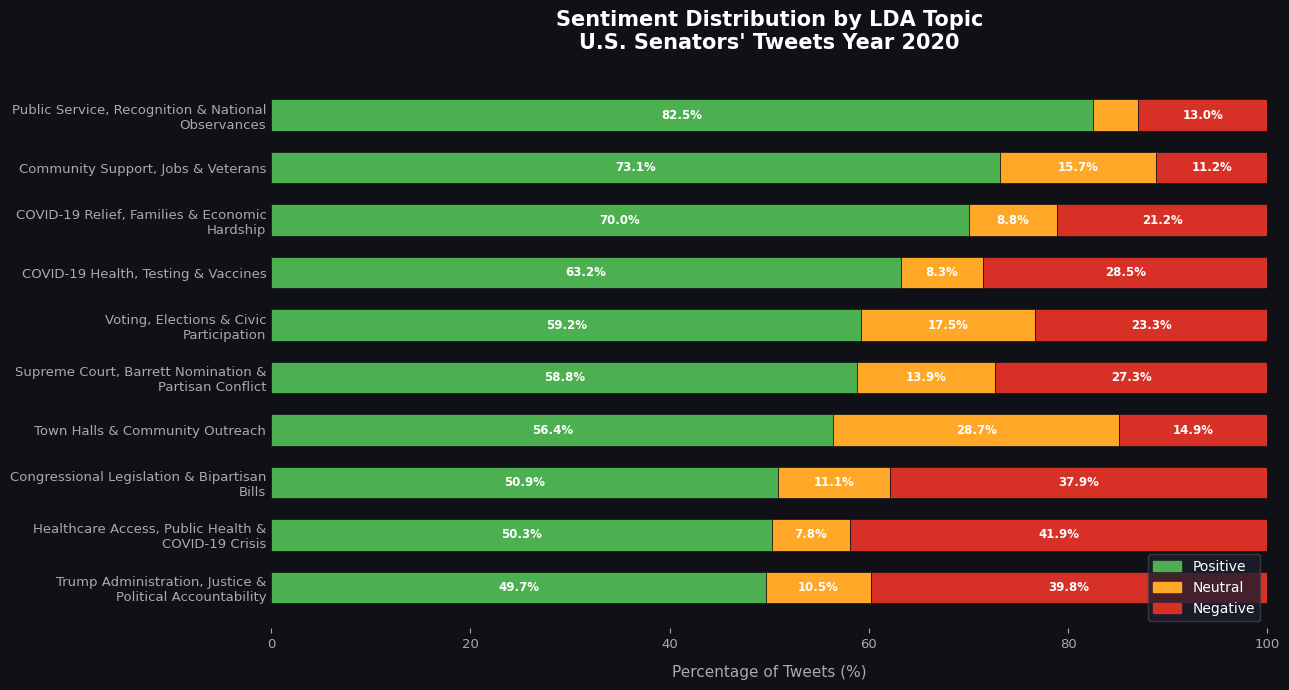

In [ ]:
# Convert to percentages
sentiment_pct = sentiment_dist.div(sentiment_dist.sum(axis=1), axis=0) * 100

# Ensure consistent column order
for col in ['positive', 'neutral', 'negative']:
    if col not in sentiment_pct.columns:
        sentiment_pct[col] = 0
sentiment_pct = sentiment_pct[['positive', 'neutral', 'negative']]

# Sort by positive % descending
sentiment_pct = sentiment_pct.sort_values('positive', ascending=True)

# Set the color palette
palette = {'positive': '#4CAF50', 'neutral': '#FFA726', 'negative': '#d73027'}

# Plot
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#0F1117')

lefts = np.zeros(len(sentiment_pct))
for col in ['positive', 'neutral', 'negative']:
    vals = sentiment_pct[col].values
    bars = ax.barh(range(len(sentiment_pct)), vals, left=lefts,
                   color=palette[col], edgecolor='#0F1117', linewidth=0.5, height=0.6)
    # Add % labels inside bars if segment wide enough
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v > 6:
            ax.text(l + v / 2, i, f'{v:.1f}%', va='center', ha='center',
                    color='white', fontsize=8.5, fontweight='bold')
    lefts += vals

# Y axis labels
wrapped = [textwrap.fill(label, width=38) for label in sentiment_pct.index]
ax.set_yticks(range(len(sentiment_pct)))
ax.set_yticklabels(wrapped, fontsize=9.5, color='#DDDDDD')

# Styling the visual
ax.set_xlim(0, 100)
ax.set_xlabel('Percentage of Tweets (%)', color='#AAAAAA', fontsize=11, labelpad=10)
ax.set_title('Sentiment Distribution by LDA Topic\nU.S. Senators\' Tweets Year 2020',
             color='white', fontsize=15, fontweight='bold', pad=18)
ax.tick_params(colors='#AAAAAA', labelsize=9.5)
ax.xaxis.set_tick_params(labelcolor='#AAAAAA')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis='y', length=0)

# Legend
legend_elements = [
    mpatches.Patch(color='#4CAF50', label='Positive'),
    mpatches.Patch(color='#FFA726', label='Neutral'),
    mpatches.Patch(color='#d73027', label='Negative'),
]
ax.legend(handles=legend_elements, loc='lower right',
          facecolor='#1E1E2E', edgecolor='#444', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('q1_sentiment_distribution_by_topic.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

**Time series**

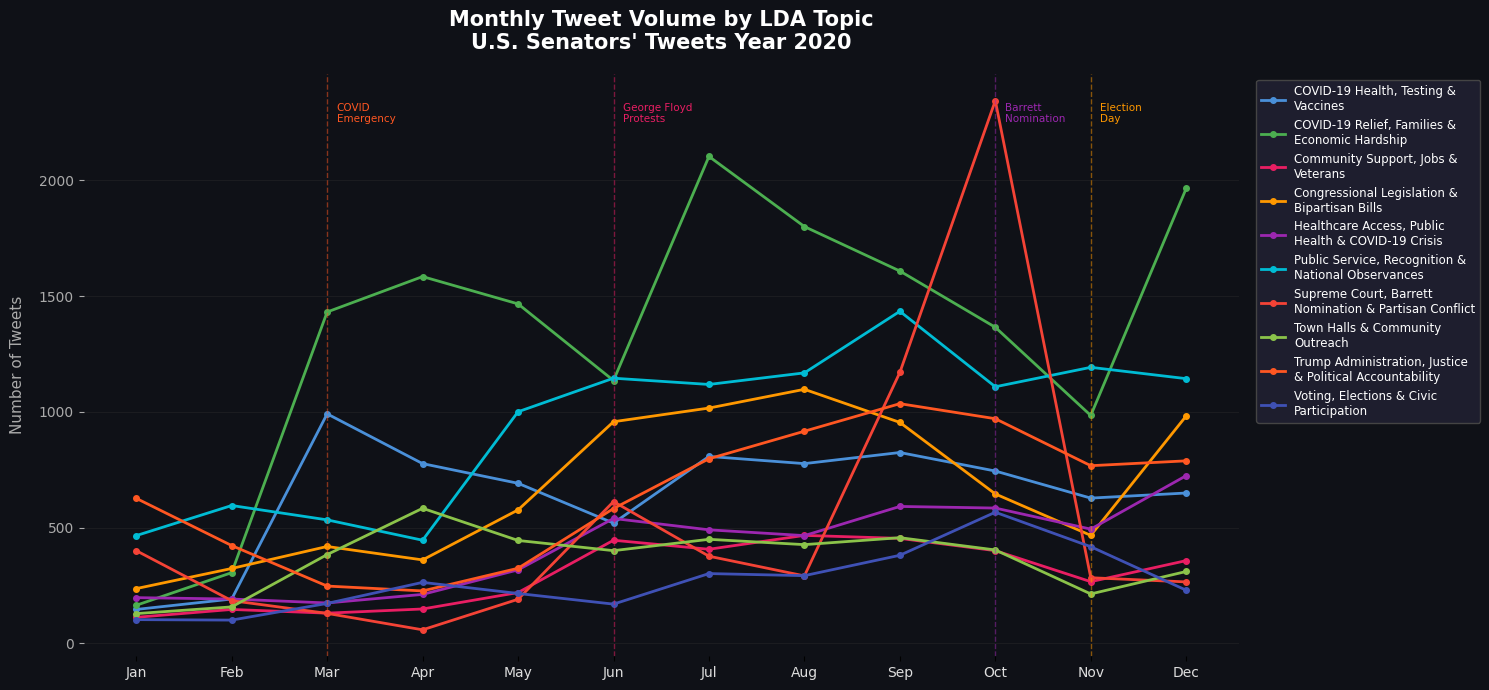

In [ ]:
# Converting timestamp
df['date'] = pd.to_datetime(df['date'], utc=True)
df['month'] = df['date'].dt.month
df['month_name'] = df['month'].map({
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
})

# Pivot: rows = months, columns = LDA topics
time_topic = df.groupby(['month', 'LDA_label']).size().unstack(fill_value=0)
time_topic.index = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']

# Color palette for 10 topics
colors = [
    '#4A90D9', '#4CAF50', '#E91E63', '#FF9800', '#9C27B0',
    '#00BCD4', '#F44336', '#8BC34A', '#FF5722', '#3F51B5'
]

# Plot
fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#0F1117')

for i, col in enumerate(time_topic.columns):
    ax.plot(range(12), time_topic[col].values,
            color=colors[i % len(colors)],
            linewidth=2, marker='o', markersize=4,
            label=textwrap.fill(col, width=30))

# Key event annotations
events = {
    2: ('COVID\nEmergency', '#FF5722'),
    5: ('George Floyd\nProtests', '#E91E63'),
    9: ('Barrett\nNomination', '#9C27B0'),
    10: ('Election\nDay', '#FF9800'),
}
for month_idx, (label, color) in events.items():
    ax.axvline(month_idx, color=color, linewidth=1,
               linestyle='--', alpha=0.5)
    ax.text(month_idx + 0.1, ax.get_ylim()[1] * 0.95,
            label, color=color, fontsize=7.5, va='top')

# Styling
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'],
                   color='#DDDDDD', fontsize=10)
ax.set_ylabel('Number of Tweets', color='#AAAAAA', fontsize=11, labelpad=10)
ax.set_title('Monthly Tweet Volume by LDA Topic\nU.S. Senators\' Tweets Year 2020',
             color='white', fontsize=15, fontweight='bold', pad=18)
ax.tick_params(axis='y', colors='#AAAAAA')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.set_tick_params(labelcolor='#AAAAAA')
ax.grid(axis='y', color='#333333', linewidth=0.5, alpha=0.5)

# Legend
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1),
          facecolor='#1E1E2E', edgecolor='#444',
          labelcolor='white', fontsize=8.5,
          framealpha=1)

plt.tight_layout()
plt.savefig('lda_time_series.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

**Model Evaluation**

In [ ]:
# Compute coherence for current model (10 topics)
coherence_model = CoherenceModel(
    model=lda,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()
print(f"Coherence Score (10 topics): {coherence_score:.4f}")

Coherence Score (10 topics): 0.4803


**BERTOPIC Modeling**

In [ ]:
%%time

# 1. Sample the dataset
df_sample = df.sample(20000, random_state=42)
docs = df_sample['cleaned_tweet_content_BERT'].tolist()

# 2. Fast embedding model
embedding_model = SentenceTransformer("sentence-transformers/paraphrase-MiniLM-L3-v2")

# 3. Fast embedding with large batch size
embeddings = embedding_model.encode(
    docs,
    batch_size=256,
    show_progress_bar=True
)

# 4. Dimensionality reduction
pca = PCA(n_components=50, random_state = 42)
reduced_embeddings = pca.fit_transform(embeddings)

# 5. Fast HDBSCAN
hdbscan_model = HDBSCAN(
    min_cluster_size=200,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=False
)

vectorizer_model = CountVectorizer(stop_words="english")

# 6. Fit BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model= hdbscan_model,
    vectorizer_model= vectorizer_model,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, reduced_embeddings)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

2026-05-13 14:38:06,583 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-13 14:38:52,836 - BERTopic - Dimensionality - Completed ✓
2026-05-13 14:38:52,838 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-13 14:39:04,019 - BERTopic - Cluster - Completed ✓
2026-05-13 14:39:04,031 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-13 14:39:04,566 - BERTopic - Representation - Completed ✓


CPU times: user 5min 29s, sys: 33 s, total: 6min 2s
Wall time: 6min 20s


In [ ]:
# Viewing BERTopics Classification
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,9349,-1_covid19_need_help_health,"[covid19, need, help, health, today, act, americans, care, im, work]","[this is a health crisis we should focus on the health issues and helping those most in need. 92 of americans are working there are people and businesses that do need help, but lets not make the situation worse with more spending than what is essential. 22, spoke with today to let them know that my office is ready to assist in any way we can to help families small businesses weather the economic and public health consequences of this pandemic., we must work together in a bipartisan way on this next covid19 response bill. we are in the middle of an unprecedented crisis. we need to get this done for the american people.]"
1,0,2496,0_veterans_happy_family_thank,"[veterans, happy, family, thank, service, great, honor, today, day, students]","[today we honor the brave men and women that have made the ultimate sacrifice to serve and protect our country. thank you to our veterans and god bless the usa. veteransday, on womenveteransday, we honor all women veterans who committed their lives to protect our nation. we recognize the hard work, bravery and sacrifice required to serve our country. so, thank you to all the dedicated women veterans of mississippi and our nation., for 100 years disabled american veterans has provided support for millions of veterans their families. our veterans sacrifice so much to protect our freedom, thank you for the way you, every member, volunteer now serve them. happy 100th birthday, .]"
2,1,2214,1_trump_senate_president_democrats,"[trump, senate, president, democrats, republicans, people, mcconnell, american, relief, americans]","[the senate has a constitutional responsibility to decide if president trumps supreme court nominee is the right person at the right time. the senate will do its work in the confirmation process and we will vote on the nominee., there is clear bipartisan consensus in the senate that its time for house democrats to end the delay and their political posturing and allow the senate to begin the impeachment trial. senate democrats call out speaker pelosi, the trump administrations covid19 response has been continues to be a disaster. with so much at stake right now, senate republicans need to join democrats to demand change with steps to protect families, communities, workers, small businesses through this crisis.]"
3,2,1064,2_small_businesses_economy_workers,"[small, businesses, economy, workers, unemployment, ppp, help, need, business, jobs]","[it was great to join the 10,000 small businesses program to talk with michigans small businesses about the ppp flexibility act and other ways we can help them bounce back from this economic crisis., congress needs to get more paycheckprotectionprogram loan funding to our small businesses. we must do our part to provide additional relief to these workers and employers., our small businesses are vital to our communities and the state economy, and right now main street needs help. thats why im proud to announce 6 million from to support small businesses impacted by the covid19 pandemic. more]"
4,3,1011,3_coronavirus_vaccine_covid19_vaccines,"[coronavirus, vaccine, covid19, vaccines, pandemic, health, help, spread, relief, need]","[arizonans can find uptodate information on the coronavirus vaccine here, for everyone whos looking for coronavirus resources coronavirus guidelines for america the federal governments coronavirus response and resource page kys coronavirus response and resource page, read more about arizonas coronavirus vaccine plan here]"
5,4,787,4_police_justice_violence_enforcement,"[police, justice, violence, enforcement, law, officers, act, black, policing, communities]","[today i joined , and to unveil the justiceinpolicing act a comprehensive approach to hold police accountable, change the culture of law enforcement and build trust between law enforcement and our comm

We applied BERTopic using MiniLM sentence embeddings and reduced the embedding dimensionality to 50 using PCA. Topic clusters were generated with HDBSCAN (min_cluster_size = 200) to ensure stable, interpretable groupings and to avoid overly fragmented topics. This configuration produced 13 coherent topics along with one outlier cluster (topic –1).

In [ ]:
# Adding BERTopics labels to the dataframe
df_sample['BERTopic_topic'] = topics

In [ ]:
# Add topic labels
topic_labels = {
    -1: "Uncategorized/Mixed",
    0:  "Veterans, Holidays & Public Appreciation",
    1:  "Trump, Senate & Political Parties",
    2:  "Small Business, Economy & Workers",
    3:  "Coronavirus Vaccines & Pandemic Response",
    4:  "Police Reform, Justice & Racial Inequality",
    5:  "Healthcare Access, Hospitals & Telehealth",
    6:  "China, CCP & Human Rights",
    7:  "Amy Coney Barrett & Supreme Court Nomination",
    8:  "Voting, Elections & Ballots",
    9:  "Live Events, Town Halls & Outreach",
    10: "Farmers, Agriculture & Food Supply",
    11: "Clean Energy, Climate Change & Water Infrastructure"
}

df_sample['BERTopic_label'] = df_sample['BERTopic_topic'].map(topic_labels)
df_sample['BERTopic_label'].value_counts()

,count
BERTopic_label,
Uncategorized/Mixed,9349
"Veterans, Holidays & Public Appreciation",2496
"Trump, Senate & Political Parties",2214
"Small Business, Economy & Workers",1064
Coronavirus Vaccines & Pandemic Response,1011
"Police Reform, Justice & Racial Inequality",787
"Healthcare Access, Hospitals & Telehealth",663
"China, CCP & Human Rights",546
Amy Coney Barrett & Supreme Court Nomination,446


In [ ]:
# Average Sentiment per topic (using labels)

df_sample['sentiment_score'] = df_sample['tweet_content'].apply(
        lambda x: sia.polarity_scores(x)['compound']
    )
df_sample['sentiment_label'] = df_sample['sentiment_score'].apply(label_sentiment)

topic_sentiment = df_sample.groupby('BERTopic_label')['sentiment_score'].mean()
topic_sentiment

,sentiment_score
BERTopic_label,
Amy Coney Barrett & Supreme Court Nomination,0.415623
"China, CCP & Human Rights",0.076705
"Clean Energy, Climate Change & Water Infrastructure",0.294295
Coronavirus Vaccines & Pandemic Response,0.325891
"Farmers, Agriculture & Food Supply",0.357153
"Healthcare Access, Hospitals & Telehealth",0.354520
"Live Events, Town Halls & Outreach",0.203229
"Police Reform, Justice & Racial Inequality",-0.083202
"Small Business, Economy & Workers",0.231592


In [ ]:
# Sentiment Distribution per topic (using labels)
sentiment_dist = df_sample.groupby(['BERTopic_label', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_dist

sentiment_label,negative,neutral,positive
BERTopic_label,,,
Amy Coney Barrett & Supreme Court Nomination,73,44,329
"China, CCP & Human Rights",221,49,276
"Clean Energy, Climate Change & Water Infrastructure",84,20,198
Coronavirus Vaccines & Pandemic Response,202,117,692
"Farmers, Agriculture & Food Supply",64,38,247
"Healthcare Access, Hospitals & Telehealth",152,30,481
"Live Events, Town Halls & Outreach",37,159,177
"Police Reform, Justice & Racial Inequality",404,38,345
"Small Business, Economy & Workers",303,72,689


**Model Evaluation**



In [ ]:
# Outlier ratio
total = len(df_sample)
outliers = (df_sample['BERTopic_topic'] == -1).sum()
outlier_ratio = outliers / total * 100
print(f"Total tweets sampled: {total}")
print(f"Outliers (topic -1): {outliers}")
print(f"Outlier ratio: {outlier_ratio:.2f}%")

Total tweets sampled: 20000
Outliers (topic -1): 9349
Outlier ratio: 46.74%


In [ ]:
# Topic Diversity (unique words across topics)
all_words = []
top_words_per_topic = []
for topic_id in sorted(df_sample['BERTopic_topic'].unique()):
    if topic_id == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(topic_id)[:10]]
    top_words_per_topic.append(words)
    all_words.extend(words)

diversity_score = len(set(all_words)) / len(all_words)
print(f"\nTopic Diversity Score: {diversity_score:.4f}")
print(f"(1.0 = fully unique words, 0.0 = all topics share same words)")


Topic Diversity Score: 0.9250
(1.0 = fully unique words, 0.0 = all topics share same words)


In [ ]:
# 3. Average topic size excluding outliers
topic_sizes = df_sample[df_sample['BERTopic_topic'] != -1]['BERTopic_topic'].value_counts()
print(f"\nNumber of topics found: {len(topic_sizes)}")
print(f"Average tweets per topic: {topic_sizes.mean():.0f}")
print(f"Largest topic: {topic_sizes.max()} tweets")
print(f"Smallest topic: {topic_sizes.min()} tweets")


Number of topics found: 12
Average tweets per topic: 888
Largest topic: 2496 tweets
Smallest topic: 302 tweets


**BERTopic Keywords Table**

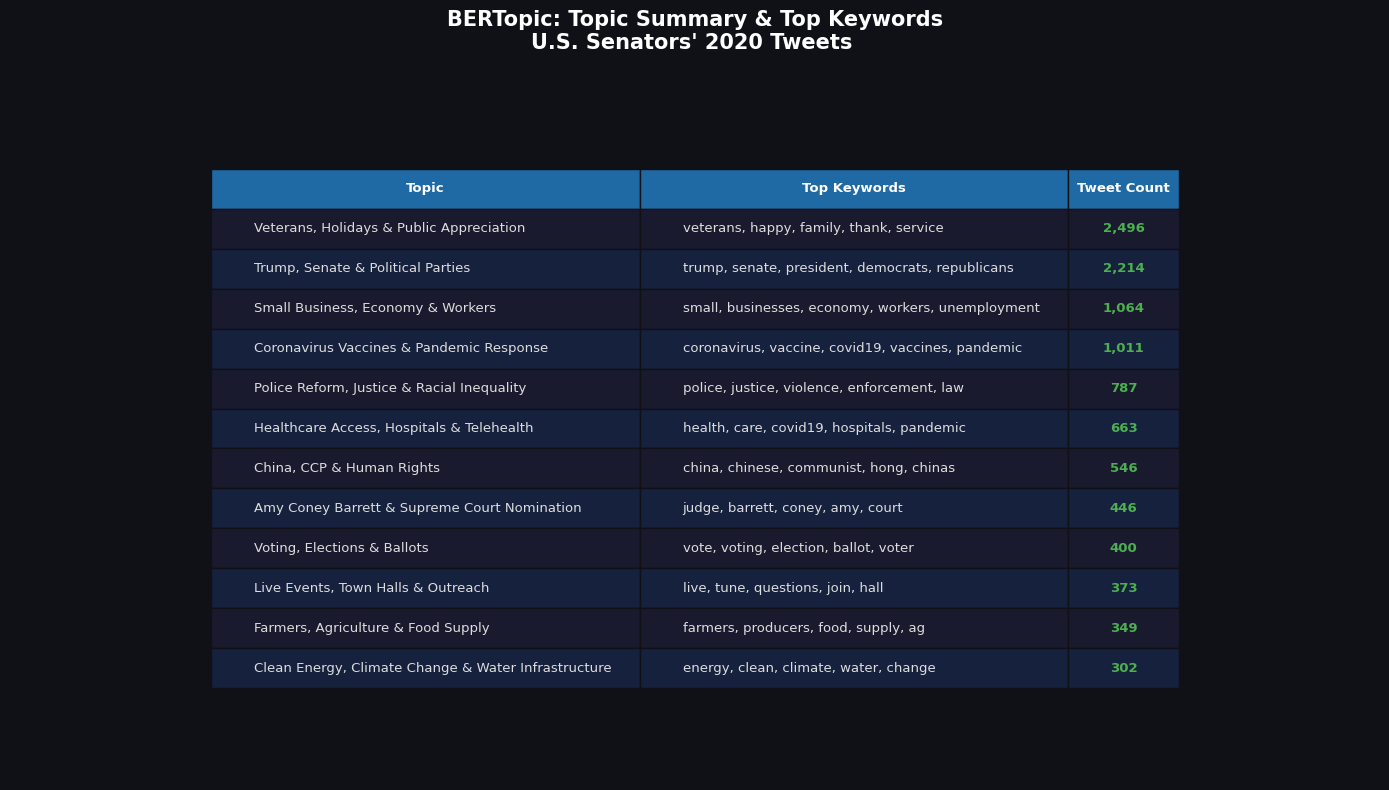

In [ ]:
# Select top 5 keywords pe topic from the model
topic_info = []
for topic_id in sorted(df_sample['BERTopic_topic'].unique()):
    if topic_id == -1:
        continue
    # Filter out stopwords from keywords
    raw_words = [word for word, _ in topic_model.get_topic(topic_id)]
    clean_words = [w for w in raw_words if w.lower() not in stop_words][:5]
    count = (df_sample['BERTopic_topic'] == topic_id).sum()
    topic_info.append({
        'label': topic_labels.get(topic_id, f"Topic {topic_id}"),
        'keywords': ', '.join(clean_words),
        'count': count
    })

# Sort by count descending
topic_info = sorted(topic_info, key=lambda x: x['count'], reverse=True)

# Plot the visual
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#0F1117')
ax.axis('off')

ax.set_title('BERTopic: Topic Summary & Top Keywords\nU.S. Senators\' 2020 Tweets ',
             color='white', fontsize=15, fontweight='bold', pad=20)

# Table the data
col_labels = ['Topic', 'Top Keywords', 'Tweet Count']
table_data = [[row['label'], row['keywords'], f"{row['count']:,}"] for row in topic_info]

# Draw the table
table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='left',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 2.1)

# Style header
for j in range(3):
    cell = table[0, j]
    cell.set_facecolor('#1F6AA5')
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('#0F1117')

# Style rows
for i, row in enumerate(table_data):
    for j in range(3):
        cell = table[i + 1, j]
        cell.set_facecolor('#1A1A2E' if i % 2 == 0 else '#16213E')
        cell.set_text_props(color='#DDDDDD')
        cell.set_edgecolor('#0F1117')
        if j == 2:  # count column center aligned
            cell.set_text_props(color='#4CAF50', fontweight='bold', ha='center')

# Column widths
table.auto_set_column_width([0, 1, 2])

plt.tight_layout()
plt.savefig('bertopic_topic_table.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

**Visualize word bar chart for top all topics**

In [ ]:
topic_model.visualize_barchart(top_n_topics=12, n_words=4)

**LDA vs BERTopic Comparison**

In [ ]:
# LDA topic counts
lda_counts = df.groupby('LDA_label').size().reset_index(name='count')
lda_counts = lda_counts[lda_counts['LDA_label'].notna()]
lda_counts = lda_counts.sort_values('count', ascending=False)

# BERTopic topic counts (exclude outliers)
bert_counts = df_sample[df_sample['BERTopic_label'] != 'Uncategorized/Mixed'] \
    .groupby('BERTopic_label').size().reset_index(name='count')
bert_counts = bert_counts.sort_values('count', ascending=False)

# Normalize to % so the two models are comparable despite different dataset sizes
lda_counts['pct'] = lda_counts['count'] / lda_counts['count'].sum() * 100
bert_counts['pct'] = bert_counts['count'] / bert_counts['count'].sum() * 100

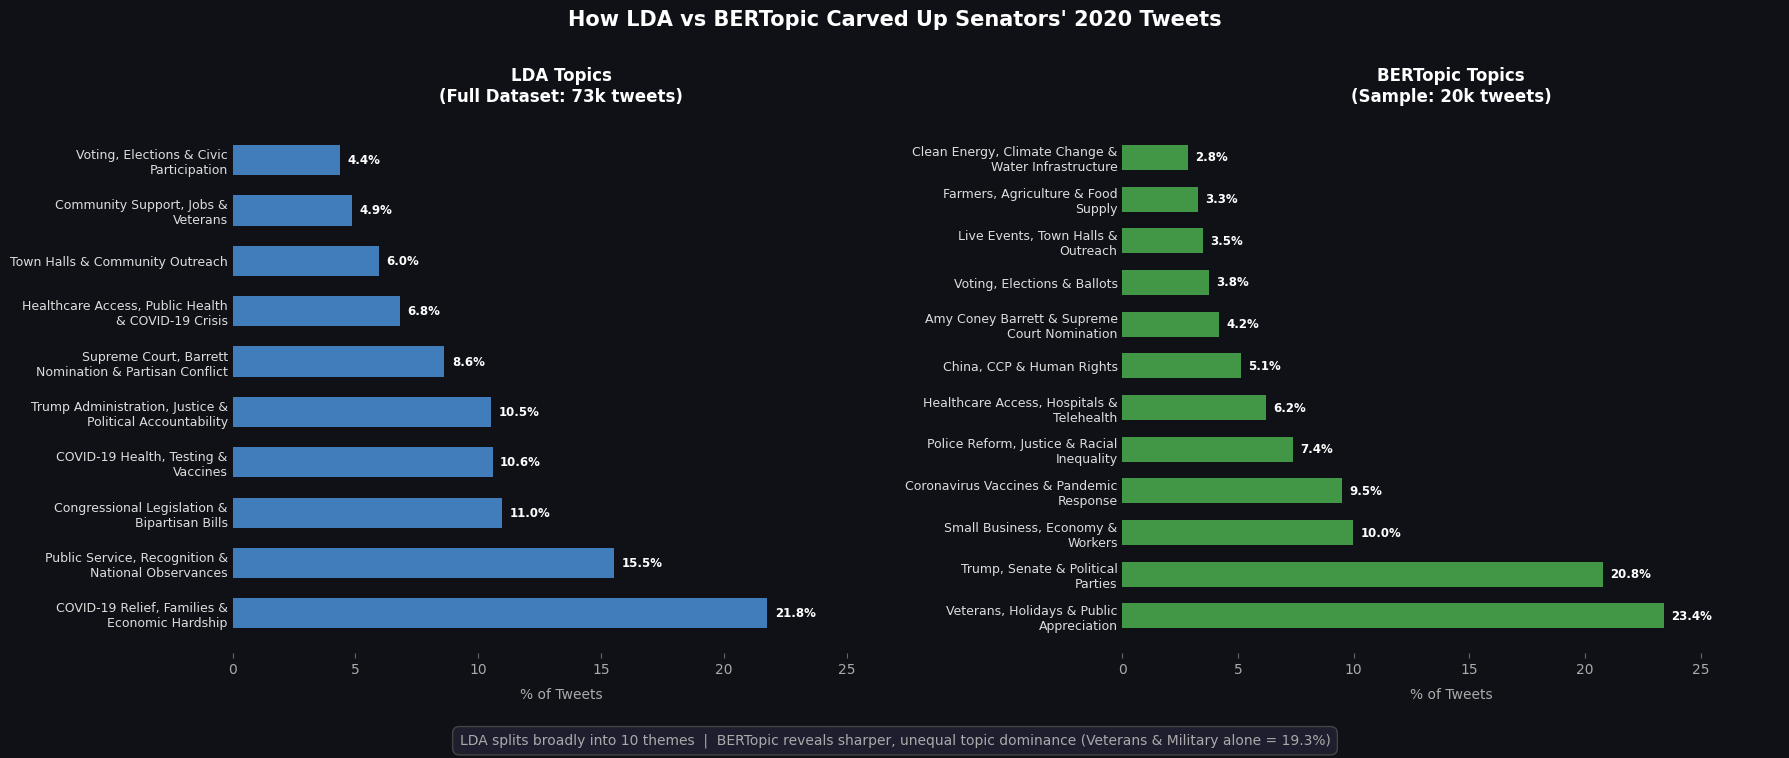

In [ ]:
# Plot the side by side horizontal bars
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0F1117')

# Color palettes
lda_color  = '#4A90D9'
bert_color = '#4CAF50'

for ax, data, color, title in [
    (ax1, lda_counts,  lda_color,  'LDA Topics\n(Full Dataset: 73k tweets)'),
    (ax2, bert_counts, bert_color, 'BERTopic Topics\n(Sample: 20k tweets)')
]:
    ax.set_facecolor('#0F1117')
    bars = ax.barh(range(len(data)), data['pct'].values,
                   color=color, height=0.6, edgecolor='none', alpha=0.85)

    # Value labels
    for bar, val in zip(bars, data['pct'].values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', ha='left',
                color='white', fontsize=8.5, fontweight='bold')

    # Y labels
    wrapped = [textwrap.fill(label, width=32) for label in data.iloc[:, 0]]
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(wrapped, fontsize=9, color='#DDDDDD')

    # Styling
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=14)
    ax.set_xlabel('% of Tweets', color='#AAAAAA', fontsize=10, labelpad=8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', colors='#666666', labelcolor='#AAAAAA')
    ax.set_xlim(0, data['pct'].max() + 5)

fig.suptitle('How LDA vs BERTopic Carved Up Senators\' 2020 Tweets',
             color='white', fontsize=15, fontweight='bold', y=1.01)

# Annotation box explaining the key difference
fig.text(0.5, -0.04,
         'LDA splits broadly into 10 themes  |  BERTopic reveals sharper, unequal topic dominance (Veterans & Military alone = 19.3%)',
         ha='center', color='#AAAAAA', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1E1E2E', edgecolor='#444'))

plt.tight_layout()
plt.savefig('lda_vs_bertopic.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

# **Question 2**: Are Republican or Democratic senators more likely to express negative sentiment in tweets related to COVID-19, elections or legislation?

In [ ]:
# Display unique senators
senators = df['username'].unique()
senators

array(['lisamurkowski', 'SenDanSullivan', 'TTuberville', 'SenShelby',
       'JohnBoozman', 'SenTomCotton', 'SenMarkKelly', 'SenatorSinema',
       'SenFeinstein', 'SenatorBennet', 'SenBlumenthal', 'SenatorCarper',
       'ChrisCoons', 'SenRubioPress', 'SenRickScott', 'maziehirono',
       'SenBrianSchatz', 'SenJoniErnst', 'ChuckGrassley', 'MikeCrapo',
       'SenatorRisch', 'SenDuckworth', 'SenatorDurbin', 'SenatorBraun',
       'SenToddYoung', 'JerryMoran', 'RogerMarshallMD', 'RandPaul',
       'SenBillCassidy', 'SenJohnKennedy', 'SenMarkey', 'SenWarren',
       'SenatorCardin', 'ChrisVanHollen', 'SenatorCollins',
       'SenAngusKing', 'SenGaryPeters', 'SenStabenow', 'SenAmyKlobuchar',
       'SenTinaSmith', 'RoyBlunt', 'SenHawleyPress', 'SenHydeSmith',
       'SenatorWicker', 'SteveDaines', 'SenatorTester', 'SenatorBurr',
       'SenThomTillis', 'SenKevinCramer', 'SenJohnHoeven',
       'SenatorFischer', 'SenSasse', 'SenatorHassan', 'SenatorShaheen',
       'SenBooker', 'SenatorMen

In [ ]:
# Mapping of senators to their respective party
party_map = {
    'lisamurkowski': 'Republican',
    'SenDanSullivan':'Republican',
    'TTuberville':'Republican',
    'SenShelby':'Republican',
    'JohnBoozman':'Republican',
    'SenTomCotton':'Republican',
    'SenMarkKelly': 'Democratic',
    'SenatorSinema': 'Independent',
    'SenFeinstein': 'Democratic',
    'SenatorBennet': 'Democratic',
    'SenBlumenthal': 'Democratic',
    'SenatorCarper': 'Democratic',
    'ChrisCoons': 'Democratic',
    'SenRubioPress':'Republican',
    'SenRickScott':'Republican',
    'maziehirono': 'Democratic',
    'SenBrianSchatz': 'Democratic',
    'SenJoniErnst':'Republican',
    'ChuckGrassley':'Republican',
    'MikeCrapo':'Republican',
    'SenatorRisch':'Republican',
    'SenDuckworth': 'Democratic',
    'SenatorDurbin': 'Democratic',
    'SenatorBraun':'Republican',
    'SenToddYoung':'Republican',
    'JerryMoran':'Republican',
    'RogerMarshallMD':'Republican',
    'RandPaul':'Republican',
    'SenBillCassidy':'Republican',
    'SenJohnKennedy':'Republican',
    'SenMarkey': 'Democratic',
    'SenMarkey': 'Democratic',
    'SenatorCardin': 'Democratic',
    'ChrisVanHollen': 'Democratic',
    'SenatorCollins':'Republican',
    'SenAngusKing': 'Independent',
    'SenGaryPeters': 'Democratic',
    'SenStabenow': 'Democratic',
    'SenAmyKlobuchar': 'Democratic',
    'SenTinaSmith': 'Democratic',
    'RoyBlunt':'Republican',
    'SenHawleyPress':'Republican',
    'SenHydeSmith':'Republican',
    'SenatorWicker':'Republican',
    'SteveDaines':'Republican',
    'SenatorTester': 'Democratic',
    'SenatorBurr':'Republican',
    'SenThomTillis':'Republican',
    'SenKevinCramer':'Republican',
    'SenJohnHoeven':'Republican',
    'SenatorFischer':'Republican',
    'SenSasse':'Republican',
    'SenatorHassan': 'Democratic',
    'SenatorShaheen': 'Democratic',
    'SenBooker': 'Democratic',
    'SenatorMenendez': 'Democratic',
    'MartinHeinrich': 'Democratic',
    'SenatorLujan': 'Democratic',
    'SenCortezMasto': 'Democratic',
    'SenJackyRosen': 'Democratic',
    'gillibrandny': 'Democratic',
    'SenSchumer': 'Democratic',
    'SenSherrodBrown': 'Democratic',
    'senrobportman': 'Republican',
    'JimInhofe': 'Republican',
    'SenatorLankford': 'Republican',
    'SenJeffMerkley': 'Democratic',
    'RonWyden': 'Democratic',
    'SenBobCasey': 'Democratic',
    'SenToomey': 'Republican',
    'SenJackReed': 'Democratic',
    'SenWhitehouse': 'Democratic',
    'LindseyGrahamSC': 'Republican',
    'SenatorTimScott': 'Republican',
    'SenatorRounds': 'Republican',
    'SenJohnThune': 'Republican',
    'BillHagertyTN': 'Republican',
    'MarshaBlackburn': 'Republican',
    'JohnCornyn': 'Republican',
    'SenTedCruz': 'Republican',
    'SenMikeLee': 'Republican',
    'SenatorRomney': 'Republican',
    'timkaine': 'Democratic',
    'MarkWarner': 'Democratic',
    'SenatorLeahy': 'Democratic',
    'SenSanders': 'Democratic',
    'SenatorCantwell': 'Democratic',
    'PattyMurray': 'Democratic',
    'SenatorBaldwin': 'Democratic',
    'SenRonJohnson': 'Republican',
    'SenCapito': 'Republican',
    'Sen_JoeManchin': 'Democratic',
    'SenJohnBarrasso': 'Republican'
}

In [ ]:
df_sample['party'] = df_sample['username'].map(party_map)

df_sample['sentiment_score'] = df_sample['tweet_content'].apply(
        lambda x: sia.polarity_scores(x)['compound']
    )
df_sample['sentiment_label'] = df_sample['sentiment_score'].apply(label_sentiment)

topic_sentiment = df_sample.groupby('BERTopic_label')['sentiment_score'].mean()
topic_sentiment
df_sample[['username','party','tweet_content']].sample(5)

,username,party,tweet_content
16861,SenatorDurbin,Democratic,"Sending best wishes to our top military leaders after they were exposed to #COVID19. Another stark reminder that no American can dismiss this virus. We need a plan to defeat the pandemic, and it starts with listening to experts and following the science. https://t.co/Ll1Q5oKhUQ"
42353,MartinHeinrich,Democratic,"There's a clear difference between supporting American Indian art ethically and legally, and exporting items that Tribes have identified as sacred.\n \nWe need to take all possible action to stop the latter and repatriate stolen culturally significant items to the rightful owners."
56623,LindseyGrahamSC,Republican,"While I share the president's concern about fraud in elections that use mail ballots as the primary source of voting, I do not support delaying the November election."
61164,MarshaBlackburn,Republican,"The @NBA doesn’t want to talk about their financial relationship with Communist China, a country responsible for some of the greatest human rights violations of all time. Why won’t Commissioner Silver address this? https://t.co/tvNXMpv2RZ"
8907,ChrisCoons,Democratic,"Proud to work on this landmark bill with you, Sen. @JohnCornyn. An investment in civics education is an investment in the future of our democracy. https://t.co/RpPn3evLs3"


In [ ]:
# BERTopic party sentiment
topic_party_sentiment_bert = df_sample[df_sample['BERTopic_label'] != 'Uncategorized/Mixed'].groupby(['BERTopic_label', 'party'])['sentiment_score'].mean()
topic_party_sentiment_bert

BERTopic_label                                       party      
Amy Coney Barrett & Supreme Court Nomination         Democratic     0.332900
                                                     Republican     0.466406
China, CCP & Human Rights                            Democratic     0.069494
                                                     Independent    0.025800
                                                     Republican     0.076515
Clean Energy, Climate Change & Water Infrastructure  Democratic     0.249944
                                                     Independent    0.445800
                                                     Republican     0.350368
Coronavirus Vaccines & Pandemic Response             Democratic     0.301345
                                                     Independent    0.239444
                                                     Republican     0.358892
Farmers, Agriculture & Food Supply                   Democratic     0.343203
                                                     Independent    0.417671
                                                     Republican     0.363092
Healthcare Access, Hospitals & Telehealth            Democratic     0.309185
                                                     Independent    0.335150
                                                     Republican     0.454318
Live Events, Town Halls & Outreach                   Democratic     0.229504
                                                     Independent    0.175922
                                                     Republican     0.187568
Police Reform, Justice & Racial Inequality           Democratic    -0.161992
                                                     Independent   -0.194156
                                                     Republican     0.027427
Small Business, Economy & Workers                    Democratic     0.158219
                                                     Independent    0.136112
                                                     Republican     0.322106
Trump, Senate & Political Parties                    Democratic    -0.087328
                                                     Independent    0.068018
                                                     Republican     0.125339
Veterans, Holidays & Public Appreciation             Democratic     0.518335
                                                     Independent    0.643347
                                                     Republican     0.604272
Voting, Elections & Ballots                          Democratic     0.250518
                                                     Independent    0.285031
                                                     Republican     0.373748
Name: sentiment_score, dtype: float64

In [ ]:
# BERTopic sentiment distribution
sentiment_party_dist_bert = df_sample[df_sample['BERTopic_label'] != 'Uncategorized/Mixed'].groupby(['BERTopic_label', 'party'])['sentiment_label'].size().unstack(fill_value=0)
sentiment_party_dist_bert

party,Democratic,Independent,Republican
BERTopic_label,,,
Amy Coney Barrett & Supreme Court Nomination,159,0,282
"China, CCP & Human Rights",77,1,467
"Clean Energy, Climate Change & Water Infrastructure",152,3,145
Coronavirus Vaccines & Pandemic Response,390,85,529
"Farmers, Agriculture & Food Supply",72,7,269
"Healthcare Access, Hospitals & Telehealth",372,8,267
"Live Events, Town Halls & Outreach",139,9,223
"Police Reform, Justice & Racial Inequality",428,9,337
"Small Business, Economy & Workers",495,17,525


In [ ]:
# BERTopic party sentiment
topic_party_sentiment_bert = df_sample[df_sample['BERTopic_label'] != 'Uncategorized/Mixed'].groupby(['BERTopic_label', 'party'])['sentiment_score'].mean()
topic_party_sentiment_bert

BERTopic_label                                       party      
Amy Coney Barrett & Supreme Court Nomination         Democratic     0.332900
                                                     Republican     0.466406
China, CCP & Human Rights                            Democratic     0.069494
                                                     Independent    0.025800
                                                     Republican     0.076515
Clean Energy, Climate Change & Water Infrastructure  Democratic     0.249944
                                                     Independent    0.445800
                                                     Republican     0.350368
Coronavirus Vaccines & Pandemic Response             Democratic     0.301345
                                                     Independent    0.239444
                                                     Republican     0.358892
Farmers, Agriculture & Food Supply                   Democratic     0.343203
                                                     Independent    0.417671
                                                     Republican     0.363092
Healthcare Access, Hospitals & Telehealth            Democratic     0.309185
                                                     Independent    0.335150
                                                     Republican     0.454318
Live Events, Town Halls & Outreach                   Democratic     0.229504
                                                     Independent    0.175922
                                                     Republican     0.187568
Police Reform, Justice & Racial Inequality           Democratic    -0.161992
                                                     Independent   -0.194156
                                                     Republican     0.027427
Small Business, Economy & Workers                    Democratic     0.158219
                                                     Independent    0.136112
                                                     Republican     0.322106
Trump, Senate & Political Parties                    Democratic    -0.087328
                                                     Independent    0.068018
                                                     Republican     0.125339
Veterans, Holidays & Public Appreciation             Democratic     0.518335
                                                     Independent    0.643347
                                                     Republican     0.604272
Voting, Elections & Ballots                          Democratic     0.250518
                                                     Independent    0.285031
                                                     Republican     0.373748
Name: sentiment_score, dtype: float64

In [ ]:
# BERTopic sentiment distribution
sentiment_party_dist_bert = df_sample[df_sample['BERTopic_label'] != 'Uncategorized/Mixed'].groupby(['BERTopic_label', 'party'])['sentiment_label'].size().unstack(fill_value=0)
sentiment_party_dist_bert

party,Democratic,Independent,Republican
BERTopic_label,,,
Amy Coney Barrett & Supreme Court Nomination,159,0,282
"China, CCP & Human Rights",77,1,467
"Clean Energy, Climate Change & Water Infrastructure",152,3,145
Coronavirus Vaccines & Pandemic Response,390,85,529
"Farmers, Agriculture & Food Supply",72,7,269
"Healthcare Access, Hospitals & Telehealth",372,8,267
"Live Events, Town Halls & Outreach",139,9,223
"Police Reform, Justice & Racial Inequality",428,9,337
"Small Business, Economy & Workers",495,17,525


In [ ]:
topic_df = df_sample[df_sample['BERTopic_label'] == 'Coronavirus Vaccines & Pandemic Response']

# Average sentiment by party
topic_party_sentiment = (topic_df.groupby('party')['sentiment_score'].mean().reset_index())

print(topic_party_sentiment)

         party  sentiment_score
0   Democratic         0.301345
1  Independent         0.239444
2   Republican         0.358892


In [ ]:
topic_df = df_sample[df_sample['BERTopic_label'] == 'Voting, Elections & Ballots']

# Average sentiment by party
topic_party_sentiment = (topic_df.groupby('party')['sentiment_score'].mean().reset_index())

print(topic_party_sentiment)

         party  sentiment_score
0   Democratic         0.250518
1  Independent         0.285031
2   Republican         0.373748


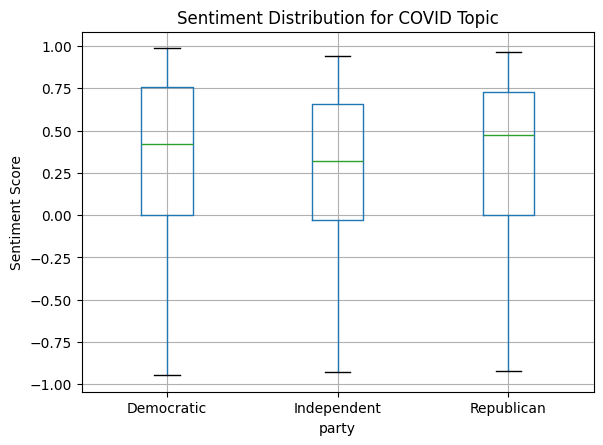

In [ ]:
import matplotlib.pyplot as plt

covid_topic = df_sample[df_sample['BERTopic_label'] == 'Coronavirus Vaccines & Pandemic Response']

covid_topic.boxplot(column='sentiment_score', by='party')

plt.title('Sentiment Distribution for COVID Topic')
plt.suptitle('')
plt.ylabel('Sentiment Score')
plt.show()

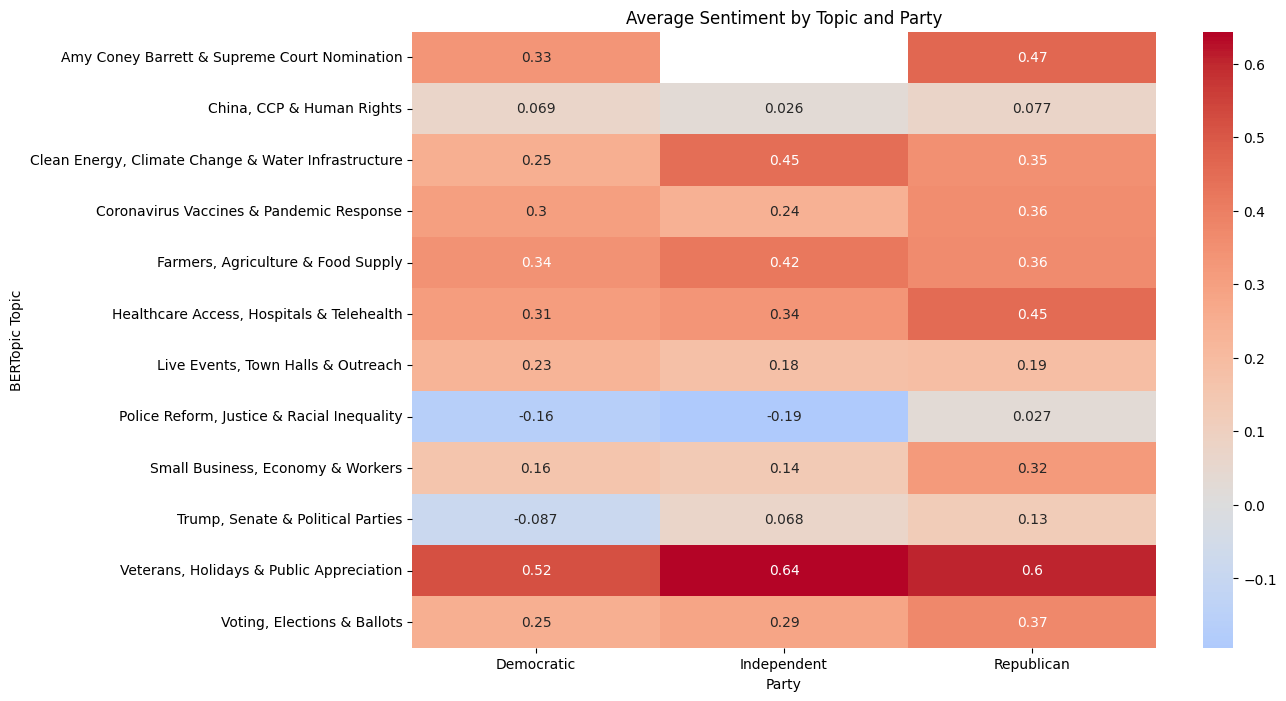

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

topic_party_sentiment = (
    df_sample[df_sample['BERTopic_label'] != 'Uncategorized/Mixed'].groupby(['BERTopic_label', 'party'])['sentiment_score']
    .mean()
    .unstack()
)

plt.figure(figsize=(12,8))
sns.heatmap(topic_party_sentiment,
            annot=True,
            cmap='coolwarm',
            center=0)

plt.title("Average Sentiment by Topic and Party")
plt.xlabel("Party")
plt.ylabel("BERTopic Topic")
plt.show()